# View data

In [3]:
import scanpy as sc
adata = sc.read_h5ad("GSE84133_subset.h5ad")
adata.obs[["celltype","sample"]]

,celltype,sample
GSM2230758_ATTGATTCT-CCTGTTAT,beta,GSM2230758
GSM2230759_GAGAATACGC-CACAAGGC,acinar,GSM2230759
GSM2230760_TGAATGACCGA-CCCTAACC,alpha,GSM2230760
GSM2230759_ACTCCGCAT-ATATAGGA,endothelial,GSM2230759
GSM2230760_TGATTGCACGC-GTTACCGC,delta,GSM2230760
...,...,...
GSM2230759_ATCCGCTA-CGAACGTA,acinar,GSM2230759
GSM2230758_CCCATCTG-TCACCGAG,ductal,GSM2230758
GSM2230757_ACCCGACTT-AGCTATGA,delta,GSM2230757
GSM2230760_GACCTATTCA-AGGTTGTG,stellate,GSM2230760


In [6]:
import pandas as pd
bulk_expression = pd.read_csv("GSE50244_expression.csv",index_col=0)
bulk_expression

,DDX11L1,WASH7P,MIR6859-1,MIR1302-2HG,MIR1302-2,FAM138A,OR4F5,LOC100996442,LOC729737,DDX11L17,...,ND4,TRNH,TRNS2,TRNL2,ND5,ND6,TRNE,CYTB,TRNT,TRNP
GSM1216753,0,65,3,0,0,0,0,29,49,0,...,93658,90,112,114,69635,17552,1134,56765,120,939
GSM1216754,0,34,1,0,0,0,0,26,20,0,...,132733,82,105,116,91913,25948,1755,71175,202,731
GSM1216755,5,106,1,0,0,0,0,24,39,6,...,97785,132,81,77,32082,16790,1758,53337,214,450
GSM1216756,0,88,2,0,0,1,0,37,41,0,...,150251,274,351,344,104479,31983,1634,75056,274,1104
GSM1216757,2,28,1,0,0,0,0,25,11,7,...,246860,248,337,341,157075,41184,3006,111694,380,1411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM1216837,4,100,7,0,0,0,0,31,35,6,...,93310,216,319,326,81948,21243,1139,60302,373,1101
GSM1216838,0,35,1,0,0,0,0,19,21,0,...,89821,94,135,133,56229,14653,956,48477,210,885
GSM1216839,11,84,1,0,0,0,0,36,21,19,...,123619,98,101,901,60278,14199,1202,57947,216,1080
GSM1216840,5,142,11,0,0,1,0,41,82,10,...,155796,360,488,545,116029,41499,2289,96255,643,1383


In [8]:
bulk_metadata = pd.read_csv("GSE50244_metadata.csv",index_col=0)
bulk_metadata

,age,bmi,gender,year_of_birth,hba1c
GSM1216753,69,24.7,Male,1939,5.8
GSM1216754,56,24.7,Male,1952,NaN
GSM1216755,46,23.9,Female,1962,5.4
GSM1216756,62,27.7,Female,1946,NaN
GSM1216757,70,17.6,Female,1939,NaN
...,...,...,...,...,...
GSM1216837,53,27.5,Male,1959,5.9
GSM1216838,54,26.1,Male,1958,5.6
GSM1216839,68,24.7,Male,1944,6.0
GSM1216840,30,22.8,Male,1982,5.6


## Step 1. Run SABER

Run `run_saber.sh` with the GSE84133 single-cell reference, GSE50244 bulk expression matrix and example configuration. The predicted cell-type proportions are written to `results/GSE50244_SABER.csv`. 

In [5]:
from pathlib import Path
import subprocess

examples_dir = Path.cwd()
subprocess.run(
    ["bash", str(examples_dir / "run_saber.sh")],
    check=True,
)


# or 
# from pathlib import Path
# import subprocess
# examples_dir = Path.cwd()
# log_file = examples_dir / "output.log"
# with open(log_file, "w") as f:
#     process = subprocess.Popen(
#         ["nohup", "bash", str(examples_dir / "run_saber.sh")],
#         stdout=f,
#         stderr=subprocess.STDOUT,
#         start_new_session=True,
#     )
# print(f"Started with PID: {process.pid}")
# print(f"Log: {log_file}")


CommandNotFoundError: Your shell has not been properly configured to use 'conda activate'.
To initialize your shell, run

    $ conda init <SHELL_NAME>

Currently supported shells are:
  - bash
  - fish
  - tcsh
  - xonsh
  - zsh
  - powershell

See 'conda init --help' for more information and options.

IMPORTANT: You may need to close and restart your shell after running 'conda init'.





[SABER] Loading config...
[SABER] Loading scRNA-seq (Source) data...
[SABER] Loading bulk (Target) data...

[SABER] Running SABER-PROP training...
[SABER] Aligning scRNA-seq and bulk RNA-seq data on common genes...
[SABER] Number of common genes: 18869
[SABER] Real Bulk transform decision: input_scale=raw/count-like, applied_log1p=True, q95=3547, q99=1.07e+04, max=3.2e+06, integer_fraction=1.000, negative_fraction=0.000; large upper expression range suggests raw/count-like data
[SABER] Target stability filter summary:
  - target transform decision: input_scale=raw/count-like, applied_log1p=True, q95=3547, q99=1.07e+04, max=3.2e+06, integer_fraction=1.000, negative_fraction=0.000; large upper expression range suggests raw/count-like data
  - total candidate genes: 18869
  - hard-filtered genes: 3842
  - stable genes: 15027
  - target near-zero genes: 1570
  - target low-variance genes: 944
  - source-zero target-high genes: 25
  - source-target shifted genes: 3549
[SABER] Reference sta

Simulating samples:   0%|          | 0/10000 [00:00<?, ?it/s]/data1/linyh/Saber/SABER/saber-deconv/saber/simulate/bulk.py:81: RuntimeWarning: overflow encountered in exp
  drop_p = 0.5 / (1.0 + np.exp(-logits))
Simulating samples: 100%|██████████| 10000/10000 [03:26<00:00, 48.32it/s]



Applying technical noise and batch effects with probabilistic masks...

Simulation complete!
[SABER] Preprocessing simulated data...
[SABER] Aligning Target Bulk genes to Source genes...
[SABER] Final Target Bulk dim: (89, 5000)
[SABER] Transforming Target Bulk to shared SABER analysis scale (auto)...
[SABER] Target Bulk transform decision reused: input_scale=raw/count-like, applied_log1p=True, q95=3547, q99=1.07e+04, max=3.2e+06, integer_fraction=1.000, negative_fraction=0.000; large upper expression range suggests raw/count-like data
[SABER] Building Source and Target DataLoaders with paired source views...
Source split: Train 8000, Val 2000
Target adaptation: 89 samples
[SABER] Initializing proportion-only SABER model and local MMD loss...
[SABER] Run proportion-only local MMD Training...

STAGE 1: Source Domain Proportion Encoder Pretraining


[Ep 01] TRAIN Total: 0.1194 (Prop: 0.1175, SrcCons: 0.0183) | VAL Total: 0.1035 (Prop: 0.1035)


...

[Ep 07] TRAIN Total: 0.0163 (Prop: 0.0145, LocalMMD: 0.1863) | VAL Total: 0.0120 (Prop: 0.0120)


[Ep 08] TRAIN Total: 0.0164 (Prop: 0.0146, LocalMMD: 0.1809) | VAL Total: 0.0119 (Prop: 0.0119)


[Ep 09] TRAIN Total: 0.0164 (Prop: 0.0146, LocalMMD: 0.1770) | VAL Total: 0.0120 (Prop: 0.0120)


[Ep 10] TRAIN Total: 0.0162 (Prop: 0.0144, LocalMMD: 0.1707) | VAL Total: 0.0119 (Prop: 0.0119)

[SABER] No model directory provided; skipping model and bulk_align.csv saving.
[SABER] PROP training completed successfully.

[SABER] Running SABER-PROP prediction on input bulk...
[Predict] Loaded, aligned, and scaled bulk data with shape: (89, 5000) (auto)
[Predict] Bulk transform: input_scale=raw/count-like, applied_log1p=True, q95=4947, q99=1.063e+04, max=8.828e+05, integer_fraction=1.000, negative_fraction=0.000; large upper expression range suggests raw/count-like data
[SABER] Proportions saved to results
[SABER] SABER-PROP completed successfully.


CompletedProcess(args=['bash', '/data1/linyh/Saber/publication/SABER/examples/run_saber.sh'], returncode=0)

## Step 2. Plot the association between HbA1c and beta-cell proportion

Match SABER beta-cell estimates to GSE50244 metadata by sample ID, retain samples with both measurements, fit a sample-level linear regression with an intercept and plot the fitted relationship. The figure is saved as PDF and PNG in `results/`.

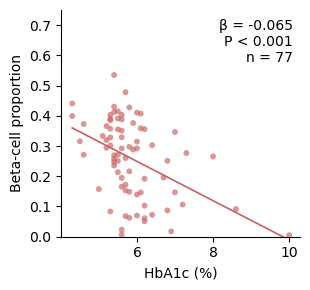

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
from pathlib import Path
examples_dir = Path.cwd()
metadata = pd.read_csv(examples_dir / "GSE50244_metadata.csv", index_col=0)
proportions = pd.read_csv(examples_dir / "results/GSE50244_SABER.csv", index_col=0)

metadata.index = metadata.index.astype(str)
proportions.index = proportions.index.astype(str)
common_samples = metadata.index.intersection(proportions.index)

analysis_data = pd.DataFrame(
    {
        "hba1c": pd.to_numeric(metadata.loc[common_samples, "hba1c"], errors="coerce"),
        "beta": pd.to_numeric(proportions.loc[common_samples, "beta"], errors="coerce"),
    }
).dropna()

fit = linregress(analysis_data["hba1c"], analysis_data["beta"])
x_line = np.linspace(analysis_data["hba1c"].min(), analysis_data["hba1c"].max(), 100)
p_label = "P < 0.001" if fit.pvalue < 0.001 else f"P = {fit.pvalue:.3f}"

fig, ax = plt.subplots(figsize=(3.2, 3.0))
ax.scatter(analysis_data["hba1c"], analysis_data["beta"], s=18, color="#C95F5F", alpha=0.65, edgecolor="none")
ax.plot(x_line, fit.intercept + fit.slope * x_line, color="#C95F5F", linewidth=1.2)
ax.text(
    0.97,
    0.96,
    f"β = {fit.slope:.3f}\n{p_label}\nn = {len(analysis_data)}",
    transform=ax.transAxes,
    ha="right",
    va="top",
)
ax.set_xlabel("HbA1c (%)")
ax.set_ylabel("Beta-cell proportion")
ax.set_ylim(0, 0.75)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(examples_dir / "results/hba1c_beta_scatter.pdf", bbox_inches="tight")
fig.savefig(examples_dir / "results/hba1c_beta_scatter.png", dpi=300, bbox_inches="tight")
plt.show()